## Exploratory Data Analysis (EDA): Impactos no NPS e Jornada do Cliente
Autor: Giusepe Lopes

Contexto: Análise de uma base de e-commerce com 2.500 registros para identificar os principais detratores da experiência do cliente e fatores de risco para a recompra.

1. Objetivos da Análise

    Cálculo do NPS Resultante: Determinar o Net Promoter Score atual da base.

    Identificação de Atrito: Analisar a correlação entre atrasos na entrega, número de reclamações e o tempo de atendimento com a nota de recomendação.

    Segmentação de Comportamento: Comparar o perfil de clientes promotores e detratores.

    Impacto no Negócio: Mensurar como falhas operacionais reduzem a taxa de recompra em 30 dias.

2. Engenharia de Variáveis (Feature Engineering)

    Para aprofundar o estudo, foram criadas as seguintes categorias:

       *is_detractor*: Segmentação binária para notas de NPS abaixo de 7.

        *tenure_category*: Classificação do tempo de casa (Curto, Médio, Longo).

        *delay_category*: Faixas de atraso (No Prazo, 1 dia, 2-3 dias, etc.).

        *delivery_commit_days*: Cálculo da promessa original de entrega.

        *customer_service_category*: Frequência de contatos com o suporte.

3. Principais Insights e Metodologias

    Fatores Críticos: Identificou-se forte correlação negativa entre o NPS e as variáveis delivery_delay_days, complaints_count e resolution_time_days.

    Taxa de Recompra: A análise revelou uma queda drástica na fidelização conforme os dias de atraso aumentam (clientes com 7+ dias de atraso apresentam 0% de taxa de recompra).

    Atendimento: Constatou-se que a resolução no primeiro contato é vital; a partir do segundo contato, o cliente tende a se tornar um detrator, independentemente da solução.

## Importação de libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import plotly.express as px
from scipy.stats import kruskal
import matplotlib.pyplot as plt

## Carga da base de dados

In [5]:
df_nps = pd.read_csv("../data/desafio_nps_fase_1.csv")
df_nps.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [83]:
# Verificando valores únicos por coluna
df_nps.nunique()

,0
customer_id,2500
customer_age,52
customer_region,5
customer_tenure_months,119
order_id,2500
order_value,2457
items_quantity,6
discount_value,2050
payment_installments,11
delivery_time_days,13


In [84]:
# Verificando os tipos de dados por coluna. Apenas 'customer_region' sendo armazenado como string.
df_nps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [85]:
# Verificando se a base possui valores nulos.
df_nps.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [86]:
df_nps.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


Constatações iniciais:


*   19 colunas
*   2500 registros

*   Sem valores nulos
*   Tratam-se de pedidos de 2500 clientes diferentes, customer_id não se repetem na base de dados.

## Distribuição da variável alvo

In [87]:
# Plota o histograma da variavel nps_score, para verificarmos sua distribuição.
px.histogram(df_nps, x='nps_score',nbins=50).show()

In [88]:
# Função para cálculo do teste Shapiro Wilk, para confirmação de distribuição não normal
def shap_wilk_test(target_column):
  """
  Recebe a coluna de um Dataframe e calcula o teste Shapiro Wilk para ela, considerando alpha=0.05 .
  Imprime o resultado e interpretação.
  """
  statistic, p_value = stats.shapiro(target_column)

  print(f"Statistic: {statistic}, p-value: {p_value}")

  alpha = 0.05
  if p_value > alpha:
      print("Amostra parece Gaussiana (falha em rejeitar H0)")
  else:
      print("Amostra não parece Gaussiana (rejeita H0)")

In [89]:
# Executando o teste para a variável nps_score
shap_wilk_test(df_nps['nps_score'])

Statistic: 0.9817448715317816, p-value: 2.143025851394468e-17
Amostra não parece Gaussiana (rejeita H0)


**Podemos perceber que a variável não possui uma distribuição normal**

## Cálculo do NPS resultante

#### ((Number of Promoters - Number of Detractors) / Total Responses) * 100.00

In [90]:
def resulting_nps(full_df, df_promoters, df_detractors):
  '''
  Função para cálculo do NPS resultante.
  Recebe o Dataframe com todos os registros, um apenas com os promotores e outro apenas com os detratores.
  Retorna o valor de NPS resultante.
  '''
  return ((len(df_promoters) - len(df_detractors))/ len(full_df)) * 100

In [91]:
# Separação dos promotores presentes na base
promoters = df_nps[df_nps['nps_score'] >= 9.0]
promoters.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.0,110.000000,110.000000
mean,1240.590909,43.627273,63.000000,51240.590909,468.084182,3.636364,32.750364,5.809091,7.936364,0.718182,37.050545,2.154545,0.672727,3.700000,9.606364,1.0,2.272727,6.037273
std,734.101876,15.455090,33.735887,734.101876,281.021604,1.618286,28.094782,3.069517,3.819980,0.779694,12.614940,0.858699,0.836211,3.215644,0.371033,0.0,1.470874,2.142058
min,23.000000,18.000000,2.000000,50023.000000,64.870000,1.000000,0.350000,1.000000,2.000000,0.000000,4.080000,1.000000,0.000000,0.000000,9.000000,1.0,0.000000,1.200000
25%,531.250000,30.250000,34.250000,50531.250000,250.725000,2.000000,7.852500,3.000000,5.000000,0.000000,27.782500,1.000000,0.000000,1.000000,9.225000,1.0,1.000000,4.725000
50%,1269.000000,43.500000,67.500000,51269.000000,402.675000,4.000000,27.370000,5.500000,8.000000,1.000000,36.255000,2.000000,0.000000,3.000000,9.600000,1.0,2.000000,6.300000
75%,1835.000000,57.750000,90.000000,51835.000000,626.285000,5.000000,51.240000,9.000000,11.750000,1.000000,45.935000,3.000000,1.000000,6.000000,10.000000,1.0,3.000000,7.500000
max,2500.000000,69.000000,119.000000,52500.000000,1372.620000,6.000000,140.730000,11.000000,14.000000,3.000000,69.430000,3.000000,4.000000,11.000000,10.000000,1.0,10.000000,10.000000


In [92]:
# Separação dos detratores presentes na base
detractors = df_nps[df_nps['nps_score'] < 7.0]
detractors.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.0,2109.000000,2109.000000
mean,1241.972499,43.403035,61.433381,51241.972499,429.309540,3.483167,29.442684,5.977715,7.994310,2.414889,38.298326,1.997155,1.632053,5.694642,3.651778,0.0,4.442390,2.536036
std,720.254234,14.794920,34.594739,720.254234,287.091872,1.683531,29.043710,3.155516,3.770449,1.426566,12.037688,0.809685,1.243670,3.440973,1.978905,0.0,1.675848,2.179704
min,1.000000,18.000000,1.000000,50001.000000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,618.000000,31.000000,32.000000,50618.000000,216.050000,2.000000,8.740000,3.000000,5.000000,1.000000,29.930000,1.000000,1.000000,3.000000,2.200000,0.0,3.000000,0.300000
50%,1239.000000,43.000000,62.000000,51239.000000,374.010000,3.000000,20.460000,6.000000,8.000000,2.000000,38.760000,2.000000,1.000000,6.000000,3.900000,0.0,4.000000,2.300000
75%,1857.000000,56.000000,91.000000,51857.000000,572.300000,5.000000,40.330000,9.000000,11.000000,3.000000,46.360000,3.000000,2.000000,9.000000,5.300000,0.0,5.000000,4.100000
max,2499.000000,69.000000,119.000000,52499.000000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,6.900000,0.0,11.000000,8.900000


In [93]:
# Order value acumulado promotores vs detratores
print("order_value acumulado dos promotores da marca = " + str(promoters['order_value'].sum()))
print("order_value acumulado dos detratores da marca = " + str(detractors['order_value'].sum()))

order_value acumulado dos promotores da marca = 51489.26
order_value acumulado dos detratores da marca = 905413.82


In [94]:
# Proporção de detratores para promotores na base de dados.
print("Proporção de detratores para promotores = " + str((len(detractors)) / (len(promoters))))

Proporção de detratores para promotores = 19.172727272727272


In [95]:
# Calculo do NPS resultante
print("NPS resultante = " + str(resulting_nps(df_nps, promoters, detractors)))

NPS resultante = -79.96


## Novas variáveis

In [96]:
# Nova coluna para classificar detratores e não detratores
df_nps['is_detractor'] = (df_nps['nps_score'] < 7.0)

In [97]:
# Nova coluna para identificar pedidos com reclamações
df_nps['has_complaints'] = (df_nps['complaints_count'] > 0)

In [98]:
# Categorias para tempo de relacionamento.
bins = [-1, 36, 60, 300]
labels = ['Curto', 'Médio', 'Longo']
df_nps['tenure_category'] = pd.cut(df_nps['customer_tenure_months'], bins=bins, labels=labels)

In [99]:
# Nova coluna para identificar pedidos atrasados.
df_nps['delayed'] = df_nps['delivery_delay_days'] > 0

In [100]:
# Variável categorica para os atrasos de entrega.
bins = [-1, 0, 1, 3, 7, 30]
labels = ['No Prazo', '1 dia', '2-3 dias', '4-7 dias', '7+ dias']
df_nps['delay_category'] = pd.cut(df_nps['delivery_delay_days'], bins=bins, labels=labels)

In [101]:
# Criando uma nova coluna para armazenar o previsão de entrega original, em dias
df_nps['delivery_commit_days'] = df_nps['delivery_time_days'] - df_nps['delivery_delay_days']

In [102]:
# Variável categorica para promessa original de entrega.
bins = [0, 1, 3, 7, 30]
labels = ['1 dia', '2-3 dias', '4-7 dias', '7+ dias']
df_nps['delivery_commit_category'] = pd.cut(df_nps['delivery_commit_days'], bins=bins, labels=labels)

In [103]:
# Criando categorias para análise de atendimento ao cliente
df_nps['contacted_support'] = df_nps['customer_service_contacts'] > 0
bins = [-1, 0, 1, 3, 30]
labels = ['0 contatos', '1 contato', '2-3 contatos', '4+ contatos']
df_nps['customer_service_category'] = pd.cut(df_nps['customer_service_contacts'], bins=bins, labels=labels)

#### order_value x detratores

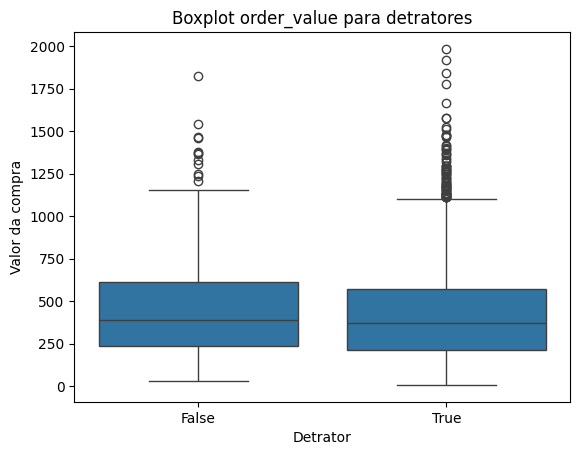

In [104]:
sns.boxplot(x='is_detractor', y='order_value', data=df_nps)
plt.title('Boxplot order_value para detratores')
plt.xlabel('Detrator')
plt.ylabel('Valor da compra')
plt.show()

#### nps_score x detratores

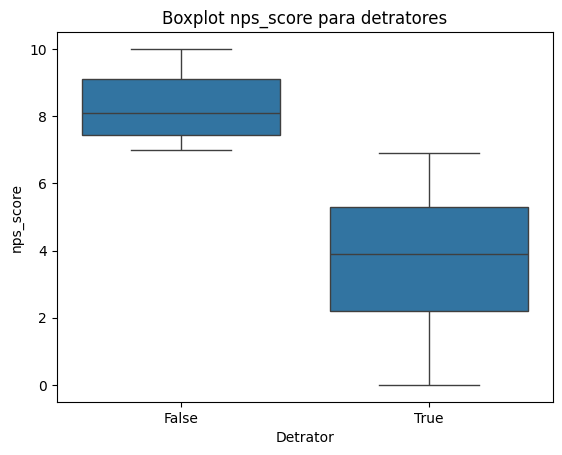

In [105]:
sns.boxplot(x='is_detractor', y='nps_score', data=df_nps)
plt.title('Boxplot nps_score para detratores')
plt.xlabel('Detrator')
plt.show()

#### Análise de perfil detratores x promotores

In [106]:
# Descrição de perfil dos promotores
promoters[['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'payment_installments', 'discount_value', 'delivery_delay_days', 'delivery_attempts', 'customer_service_contacts', 'complaints_count', 'resolution_time_days', 'repeat_purchase_30d']].describe()

,customer_age,customer_tenure_months,order_value,items_quantity,payment_installments,discount_value,delivery_delay_days,delivery_attempts,customer_service_contacts,complaints_count,resolution_time_days,repeat_purchase_30d
count,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.0
mean,43.627273,63.000000,468.084182,3.636364,5.809091,32.750364,0.718182,2.154545,0.672727,2.272727,3.700000,1.0
std,15.455090,33.735887,281.021604,1.618286,3.069517,28.094782,0.779694,0.858699,0.836211,1.470874,3.215644,0.0
min,18.000000,2.000000,64.870000,1.000000,1.000000,0.350000,0.000000,1.000000,0.000000,0.000000,0.000000,1.0
25%,30.250000,34.250000,250.725000,2.000000,3.000000,7.852500,0.000000,1.000000,0.000000,1.000000,1.000000,1.0
50%,43.500000,67.500000,402.675000,4.000000,5.500000,27.370000,1.000000,2.000000,0.000000,2.000000,3.000000,1.0
75%,57.750000,90.000000,626.285000,5.000000,9.000000,51.240000,1.000000,3.000000,1.000000,3.000000,6.000000,1.0
max,69.000000,119.000000,1372.620000,6.000000,11.000000,140.730000,3.000000,3.000000,4.000000,10.000000,11.000000,1.0


In [107]:
# Descrição de perfil dos detratores
detractors[['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'payment_installments', 'discount_value', 'delivery_delay_days', 'delivery_attempts', 'customer_service_contacts', 'complaints_count', 'resolution_time_days', 'repeat_purchase_30d']].describe()

,customer_age,customer_tenure_months,order_value,items_quantity,payment_installments,discount_value,delivery_delay_days,delivery_attempts,customer_service_contacts,complaints_count,resolution_time_days,repeat_purchase_30d
count,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.0
mean,43.403035,61.433381,429.309540,3.483167,5.977715,29.442684,2.414889,1.997155,1.632053,4.442390,5.694642,0.0
std,14.794920,34.594739,287.091872,1.683531,3.155516,29.043710,1.426566,0.809685,1.243670,1.675848,3.440973,0.0
min,18.000000,1.000000,7.760000,1.000000,1.000000,0.020000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0
25%,31.000000,32.000000,216.050000,2.000000,3.000000,8.740000,1.000000,1.000000,1.000000,3.000000,3.000000,0.0
50%,43.000000,62.000000,374.010000,3.000000,6.000000,20.460000,2.000000,2.000000,1.000000,4.000000,6.000000,0.0
75%,56.000000,91.000000,572.300000,5.000000,9.000000,40.330000,3.000000,3.000000,2.000000,5.000000,9.000000,0.0
max,69.000000,119.000000,1983.810000,6.000000,11.000000,230.330000,8.000000,3.000000,7.000000,11.000000,11.000000,0.0


#### Recompra

In [108]:
# Verificando a taxa de recompra geral do negócio
print('Taxa de recompra atual: ' + str((df_nps['repeat_purchase_30d'].sum() / df_nps['customer_id'].count()) * 100) + '%')

Taxa de recompra atual: 8.72%


In [109]:
# Total de detratores que recompraram nos últimos 30 dias.
print("Total de detratores que recompraram nos últimos 30 dias = " + str(df_nps[df_nps["is_detractor"] == True]['repeat_purchase_30d'].sum()))

Total de detratores que recompraram nos últimos 30 dias = 0


#### Top 10 pedidos de maior valor

In [110]:
# Top 10 pedidos de maior valor.
df_nps.sort_values(by='order_value', ascending=False).head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,csat_internal_score,is_detractor,has_complaints,tenure_category,delayed,delay_category,delivery_commit_days,delivery_commit_category,contacted_support,customer_service_category
211,212,41,Sul,106,50212,1983.81,5,48.50,2,13,...,1.2,True,True,Longo,True,1 dia,12,7+ dias,True,1 contato
445,446,23,Norte,80,50446,1915.89,4,37.40,2,8,...,4.3,True,True,Longo,True,2-3 dias,5,4-7 dias,True,2-3 contatos
1342,1343,60,Centro-Oeste,47,51343,1842.30,1,6.68,2,14,...,0.0,True,True,Médio,True,4-7 dias,10,7+ dias,True,4+ contatos
1898,1899,55,Sul,22,51899,1826.22,2,58.33,6,4,...,7.2,False,True,Curto,False,No Prazo,4,4-7 dias,True,1 contato
2140,2141,26,Centro-Oeste,58,52141,1775.08,2,39.88,5,11,...,5.7,True,True,Médio,True,1 dia,10,7+ dias,True,1 contato
1917,1918,32,Centro-Oeste,87,51918,1668.29,4,6.11,2,10,...,1.5,True,True,Longo,True,4-7 dias,6,4-7 dias,False,0 contatos
1743,1744,54,Centro-Oeste,115,51744,1579.63,6,28.00,1,6,...,0.0,True,True,Longo,True,4-7 dias,1,1 dia,True,2-3 contatos
2370,2371,36,Norte,52,52371,1578.50,2,46.19,8,6,...,0.0,True,True,Médio,True,2-3 dias,3,2-3 dias,True,1 contato
2439,2440,33,Centro-Oeste,88,52440,1541.74,3,30.64,6,3,...,5.2,False,True,Longo,False,No Prazo,3,2-3 dias,False,0 contatos
229,230,51,Nordeste,32,50230,1522.94,3,24.33,9,13,...,1.3,True,True,Curto,True,2-3 dias,11,7+ dias,True,2-3 contatos


#### Detratores por categoria de relacionamento

In [111]:
# Total de detratores por categoria de relacionamento.
df_nps[df_nps['is_detractor'] == True].groupby('tenure_category')['customer_id'].count()

/tmp/ipykernel_3979/3056942855.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,customer_id
tenure_category,
Curto,615
Médio,412
Longo,1082


1082 clientes com relacionamento de mais de 60 meses (5 anos) presentes no grupo de detratores.

#### NPS detratores x tempo de relacionamento

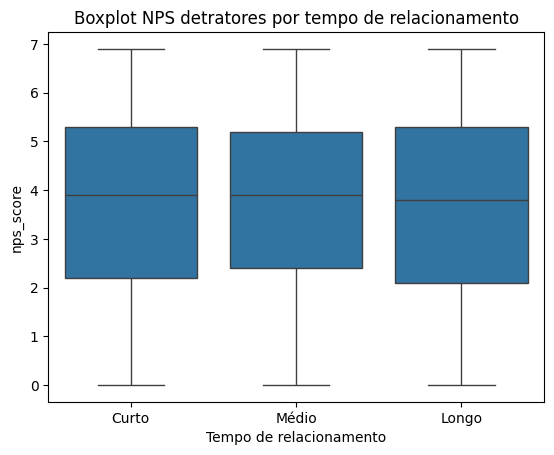

In [112]:
sns.boxplot(x='tenure_category', y='nps_score', data=df_nps[df_nps['is_detractor'] == True])
plt.title('Boxplot NPS detratores por tempo de relacionamento')
plt.xlabel('Tempo de relacionamento')
plt.show()

## Correlação com a variável alvo

In [113]:
df_nps.dtypes

,0
customer_id,int64
customer_age,int64
customer_region,object
customer_tenure_months,int64
order_id,int64
order_value,float64
items_quantity,int64
discount_value,float64
payment_installments,int64
delivery_time_days,int64


In [114]:
# Cria um dataframe de trabalho apenas com as variáveis numéricas da base.
df_nps_num = df_nps.drop(labels=['customer_region', 'is_detractor', 'has_complaints', 'tenure_category', 'delayed', 'delay_category', 'delivery_commit_category', 'contacted_support', 'customer_service_category'], axis=1)

# Calcula a matriz de correlação para as variáveis numéricas.
corr_matrix = df_nps_num.corr()

# Reduz corr_matrix apenas para correlações com a variável alvo.
nps_corr = corr_matrix[['nps_score']].sort_values(ascending=False, by='nps_score')
nps_corr

,nps_score
nps_score,1.000000
repeat_purchase_30d,0.570324
csat_internal_score,0.563952
delivery_commit_days,0.215342
order_value,0.036990
delivery_attempts,0.027680
discount_value,0.025104
payment_installments,0.023718
order_id,0.015162
customer_id,0.015162


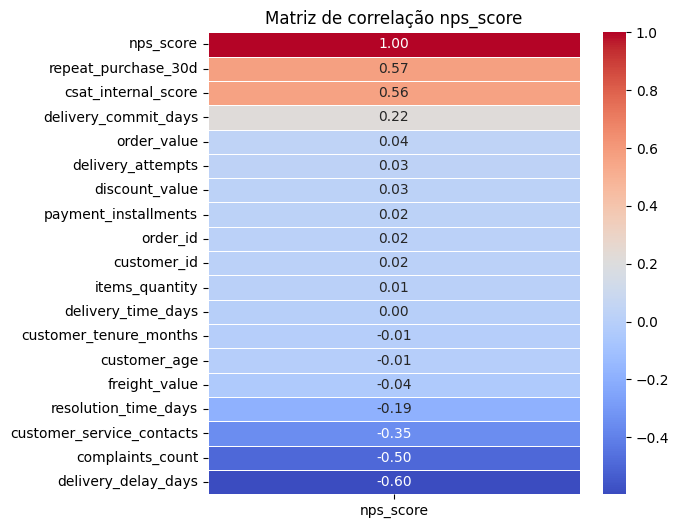

In [115]:
# Constrói e plota o gráfico de mapa de calor correspondente às correlações com nps_score.
plt.figure(figsize=(6,6))
sns.heatmap(nps_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de correlação nps_score')
plt.show()

In [116]:
# Média das variáveis correlacionadas negativamente, para promotores e detratores.
df_nps.groupby('is_detractor')[['delivery_delay_days', 'complaints_count', 'resolution_time_days']].mean()

,delivery_delay_days,complaints_count,resolution_time_days
is_detractor,,,
False,0.959079,2.575448,4.358056
True,2.414889,4.442390,5.694642


## Segmentação do NPS resultante a partir das características que contribuem mais negativamente

In [117]:
no_complaints_delay_p = promoters[(promoters['complaints_count'] == 0) & (promoters['delivery_delay_days'] == 0)]
no_complaints_delay_d = detractors[(detractors['complaints_count'] == 0) & (detractors['delivery_delay_days'] == 0)]

print("NPS resultante para pedidos sem reclamações e sem atraso: " + str(resulting_nps(df_nps, no_complaints_delay_p, no_complaints_delay_d)))

NPS resultante para pedidos sem reclamações e sem atraso: 0.2


In [118]:
complaints_only_p = promoters[(promoters['complaints_count'] > 0) & (promoters['delivery_delay_days'] == 0)]
complaints_only_d = detractors[(detractors['complaints_count'] > 0) & (detractors['delivery_delay_days'] == 0)]

print("NPS resultante para pedidos apenas com reclamações: " + str(resulting_nps(df_nps, complaints_only_p, complaints_only_d)))

NPS resultante para pedidos apenas com reclamações: -3.92


In [119]:
delay_only_p = promoters[(promoters['complaints_count'] == 0) & (promoters['delivery_delay_days'] > 0)]
delay_only_d = detractors[(detractors['complaints_count'] == 0) & (detractors['delivery_delay_days'] > 0)]

print("NPS resultante para pedidos apenas com atraso: " + str(resulting_nps(df_nps, delay_only_p, delay_only_d)))

NPS resultante para pedidos apenas com atraso: 0.0


In [120]:
complaints_delay_p = promoters[(promoters['complaints_count'] > 0) & (promoters['delivery_delay_days'] > 0)]
complaints_delay_d = detractors[(detractors['complaints_count'] > 0) & (detractors['delivery_delay_days'] > 0)]

print("NPS resultante para pedidos com reclamações e atraso: " + str(resulting_nps(df_nps, complaints_delay_p, complaints_delay_d)))

NPS resultante para pedidos com reclamações e atraso: -76.24


## Cruzamento de scores CSAT vs NPS

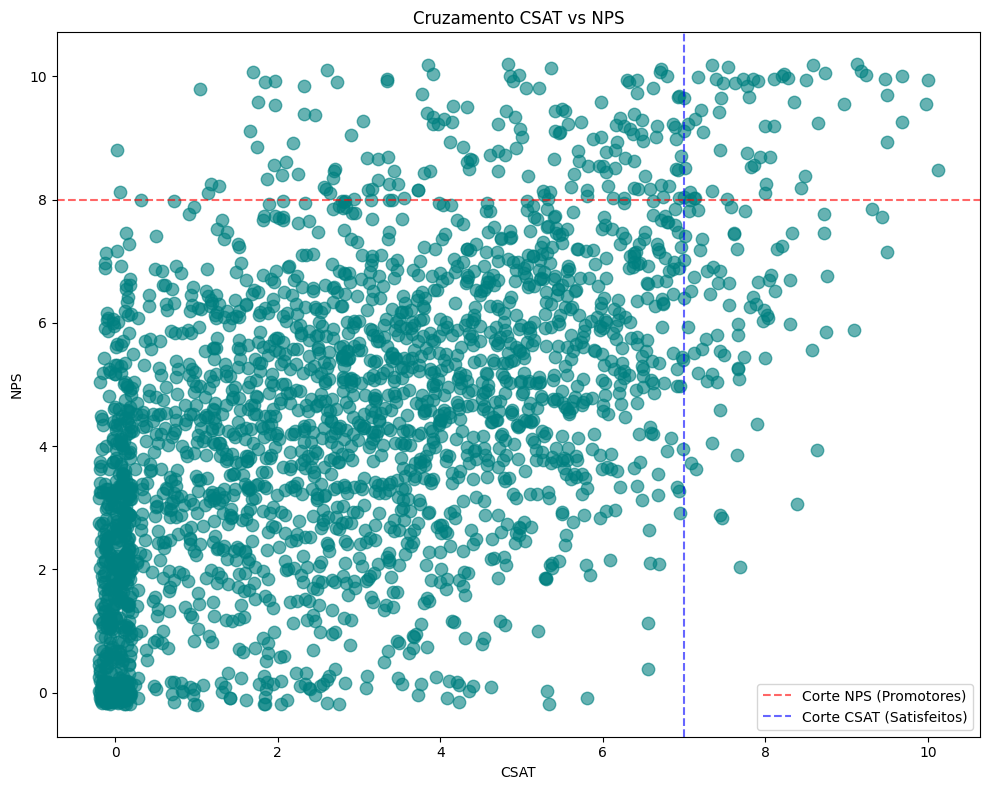

In [121]:
plt.figure(figsize=(10, 8))

# Scatterplot adicionando um pequeno jitter para melhor visualização
sns.regplot(data=df_nps, x='csat_internal_score', y='nps_score', fit_reg=False, scatter_kws={'alpha':0.6, 's':80, 'color':'teal'},x_jitter=0.2, y_jitter=0.2)

# Linhas de corte dos quadrantes. Usamos 7 para CSAT e 8 para NPS como "sucesso"
plt.axhline(y=8, color='red', linestyle='--', alpha=0.6, label='Corte NPS (Promotores)')
plt.axvline(x=7, color='blue', linestyle='--', alpha=0.6, label='Corte CSAT (Satisfeitos)')

# Legendas do gráfico.
plt.title('Cruzamento CSAT vs NPS')
plt.xlabel('CSAT')
plt.ylabel('NPS')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

Maior concentração de clientes está abaixo das linhas de corte CSAT & NPS, detratores totais.

## Análise de atraso na entrega

In [122]:
df_delayed_delivery = df_nps[df_nps['delayed'] == True]
df_ontime_delivery = df_nps[df_nps['delayed'] == False]

# Total de pedidos entregues com atraso
print("Total de pedidos entregues com atraso = " + str(len(df_delayed_delivery)))

Total de pedidos entregues com atraso = 2223


In [123]:
# Total de pedidos entregues em tempo.
print("Total de pedidos entregues em tempo = " + str(len(df_ontime_delivery)))

Total de pedidos entregues em tempo = 277


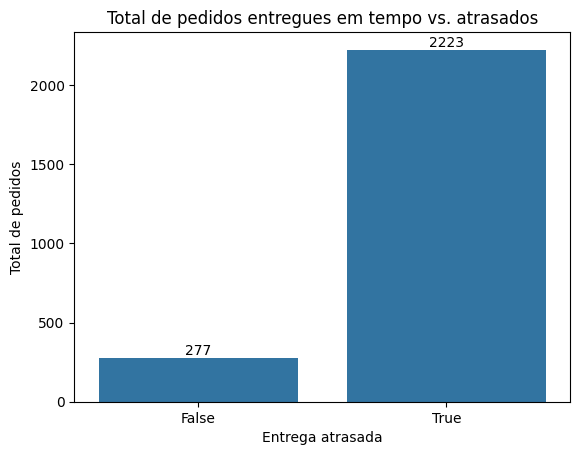

In [124]:
# Grafico de barras para representar total de pedidos em atraso.
bar_graphic = sns.barplot(data = df_nps.groupby('delayed')['customer_id'].count().reset_index(), x = 'delayed', y='customer_id')
bar_graphic.bar_label(bar_graphic.containers[0])
plt.title('Total de pedidos entregues em tempo vs. atrasados')
plt.xlabel('Entrega atrasada')
plt.ylabel('Total de pedidos')
plt.show()

In [125]:
# Estatísticas descritivas do NPS para pedidos com atraso na entrega
df_delayed_delivery['nps_score'].describe()

,nps_score
count,2223.000000
mean,4.069816
std,2.392110
min,0.000000
25%,2.300000
50%,4.100000
75%,5.750000
max,10.000000


In [126]:
# Estatísticas descritivas do NPS para pedidos com entrega dentro do prazo
df_ontime_delivery['nps_score'].describe()

,nps_score
count,277.000000
mean,6.856679
std,2.013667
min,1.100000
25%,5.500000
50%,6.800000
75%,8.500000
max,10.000000


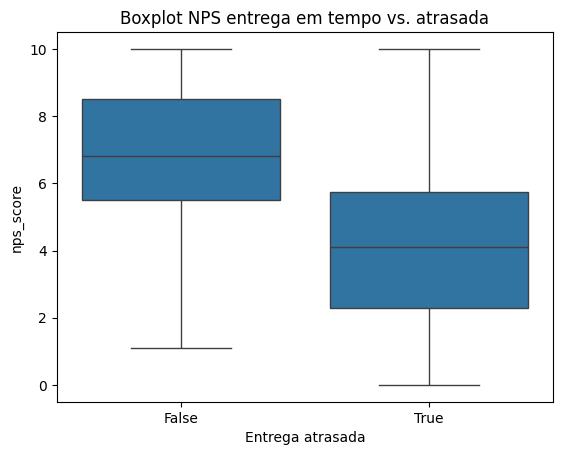

In [127]:
# Boxplot do NPS entrega em tempo X atrasada.
sns.boxplot(x='delayed', y='nps_score', data=df_nps)
plt.title('Boxplot NPS entrega em tempo vs. atrasada')
plt.xlabel('Entrega atrasada')
plt.show()

Observamos uma média de 2.787 pontos NPS maior para pedidos entregues no prazo, com mediana 2.7 pontos acima também.

In [128]:
# Taxa de recompra de clientes com pedidos que atrasaram.
print("Recompra de clientes com pedidos que atrasaram = " + str((df_delayed_delivery['repeat_purchase_30d'].sum() / len(df_delayed_delivery)) * 100))

Recompra de clientes com pedidos que atrasaram = 5.578047683310841


In [129]:
# Taxa de recompra de clientes com pedidos que chegaram no tempo previsto.
print("Recompra de clientes com pedidos que chegaram no tempo previsto = " + str((df_ontime_delivery['repeat_purchase_30d'].sum() / len(df_ontime_delivery)) * 100))

Recompra de clientes com pedidos que chegaram no tempo previsto = 33.935018050541515


Há uma queda na taxa de recompra de 28.357% devido ao atraso no prazo de entrega.

In [130]:
print("Total de clientes que recompram, por cada categoria de atraso: \n" + str(df_nps.groupby('delay_category')['repeat_purchase_30d'].sum()))
print("Total de pedidos atrasados, por categoria: \n" + str(df_nps.groupby('delay_category')['customer_id'].count()))

Total de clientes que recompram, por cada categoria de atraso: 
delay_category
No Prazo    94
1 dia       91
2-3 dias    32
4-7 dias     1
7+ dias      0
Name: repeat_purchase_30d, dtype: int64
Total de pedidos atrasados, por categoria: 
delay_category
No Prazo     277
1 dia        615
2-3 dias    1171
4-7 dias     434
7+ dias        3
Name: customer_id, dtype: int64


/tmp/ipykernel_3979/3628470499.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_3979/3628470499.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Taxa de recompra por categoria de dias de atraso:

**No prazo** = 33.93%

**1 dia** = 14.79%

**2-3 dias** = 2.73%

**4-7 dias** = 0,23%

**7+ dias** = 0%

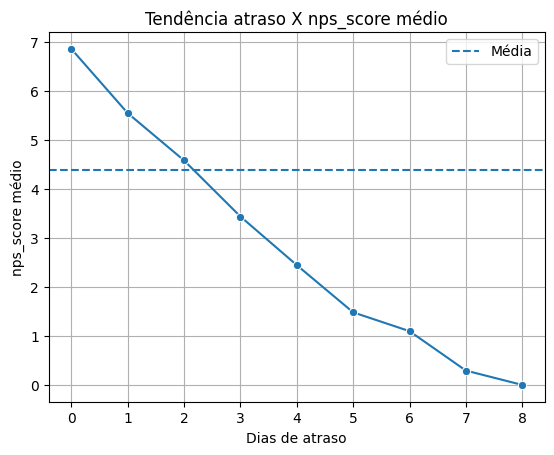

In [131]:
# Grafico de linha que mostra o impacto de cada dia de atraso na média de NPS.
sns.lineplot(data=df_nps.groupby('delivery_delay_days')['nps_score'].mean().reset_index(), x='delivery_delay_days', y='nps_score', marker='o')

# Traça uma linha de referência exatamente no valor médio do NPS score.
plt.axhline(df_nps['nps_score'].mean(), linestyle='--', label='Média')

plt.title('Tendência atraso X nps_score médio')
plt.xlabel('Dias de atraso')
plt.ylabel('nps_score médio')
plt.grid(True)
plt.legend()
plt.show()

In [132]:
# nps_score médio agrupado por dia de atraso na entrega
df_nps.groupby('delivery_delay_days')['nps_score'].mean()

,nps_score
delivery_delay_days,
0,6.856679
1,5.546179
2,4.580186
3,3.436762
4,2.444444
5,1.481034
6,1.097059
7,0.292857
8,0.000000


In [133]:
# Total de pedidos por categoria de entrega original.
df_nps.groupby('delivery_commit_category')['customer_id'].count()

/tmp/ipykernel_3979/3920304665.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,customer_id
delivery_commit_category,
1 dia,168
2-3 dias,358
4-7 dias,777
7+ dias,930


In [134]:
# Total de reclamações por categoria de entrega original.
df_nps[df_nps['has_complaints'] == True].groupby('delivery_commit_category')['complaints_count'].sum()

/tmp/ipykernel_3979/1540896289.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,complaints_count
delivery_commit_category,
1 dia,750
2-3 dias,1483
4-7 dias,3192
7+ dias,3772


## Análise do NPS por região

In [135]:
# Função para cálculo do teste de Kruskal–Wallis
def kruskal_wallis_test(df, group_col, value_col):
  """
  Recebe um Dataframe, o nome da coluna que contém o grupo sob análise, e a coluna do valor sendo avaliado.
  Calcula o teste Kruskal-Wallis e imprime o resultado.
  """
  group_list = [df[df[group_col] == val][value_col] for val in df[group_col].unique()]

  stat, p_value = kruskal(*group_list)

  print("Estatística H:", stat)
  print("p-valor:", p_value)

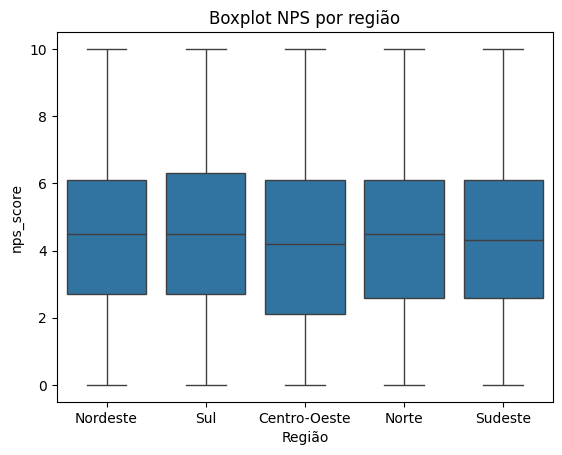

In [136]:
# Boxplot do NPS por região.
sns.boxplot(x='customer_region', y='nps_score', data=df_nps)
plt.title('Boxplot NPS por região')
plt.xlabel('Região')
plt.show()

In [137]:
# Cálculo de estatísticas descritivas sobre nps_score, para cada região.
df_nps.groupby('customer_region')['nps_score'].describe()

,count,mean,std,min,25%,50%,75%,max
customer_region,,,,,,,,
Centro-Oeste,468.0,4.209829,2.625968,0.0,2.100,4.2,6.1,10.0
Nordeste,485.0,4.421649,2.434829,0.0,2.700,4.5,6.1,10.0
Norte,506.0,4.382609,2.485931,0.0,2.600,4.5,6.1,10.0
Sudeste,520.0,4.373846,2.491552,0.0,2.575,4.3,6.1,10.0
Sul,521.0,4.490979,2.516739,0.0,2.700,4.5,6.3,10.0


In [138]:
# Cálculo de estatísticas descritivas sobre dias atrasados, para cada região.
df_delayed_delivery.groupby('customer_region')['delivery_delay_days'].describe()

,count,mean,std,min,25%,50%,75%,max
customer_region,,,,,,,,
Centro-Oeste,410.0,2.536585,1.291264,1.0,2.0,2.0,3.0,7.0
Nordeste,437.0,2.425629,1.258761,1.0,1.0,2.0,3.0,7.0
Norte,445.0,2.438202,1.345288,1.0,1.0,2.0,3.0,8.0
Sudeste,473.0,2.437632,1.282551,1.0,1.0,2.0,3.0,8.0
Sul,458.0,2.467249,1.355763,1.0,1.0,2.0,3.0,7.0


In [139]:
kruskal_wallis_test(df_nps, 'customer_region', 'nps_score')

Estatística H: 3.3787046705910635
p-valor: 0.4965595127048903


NPS médio para cada região do Brasil é bem próximo.

**NPS médio mais alto na região Sul**, onde também tivemos maior número de compras.

**NPS médio mais baixo na região Centro-Oeste**, que também possui o menor número de registros.

Como nps_score não segue uma distribuição normal, para verificar significância estatística para variação de NPS por região, utilizamos o teste Kruskal-Wallis.

**Como o valor p calculado foi 0.4965 (muito maior que 0.05), não é possível rejeitar H0, portanto não verificamos significância estatística para variação de NPS por região.**

## Cruzamento customer_region X delivery_delay_days X nps_score

/tmp/ipykernel_3979/2231056428.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



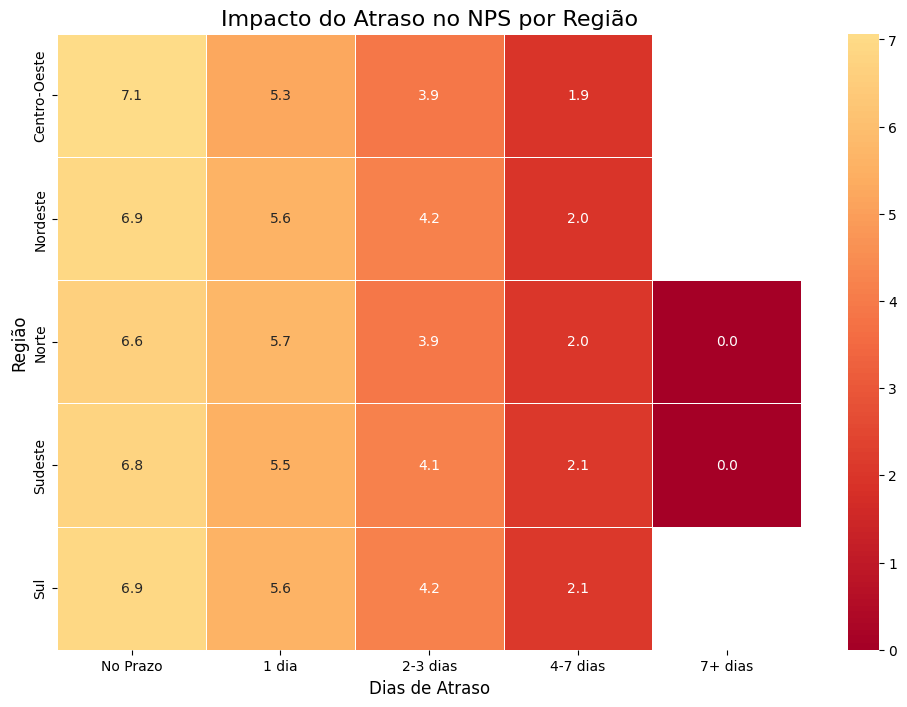

In [140]:
# Constroi um mapa de calor para visualizar o impacto do número de dias em atraso no valor do NPS médio de cada região.
heatmap_data = df_nps.pivot_table(index='customer_region', columns='delay_category', values='nps_score', aggfunc='mean')

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,       # Mostra o valor do NPS dentro de cada quadrado
    fmt=".1f",        # Formata para 1 casa decimal
    cmap="RdYlGn",    # Seleciona a escala de cores red, yellow, green
    center=9,         # Define 9 como ponto central, separando neutros de promotores.
    linewidths=.5    # Separa os quadrados do mapa com uma linha
    )

plt.title('Impacto do Atraso no NPS por Região', fontsize=16)
plt.xlabel('Dias de Atraso', fontsize=12)
plt.ylabel('Região', fontsize=12)
plt.show()

## Análise de reclamações

In [141]:
print("Total de pedidos com reclamação = " + str(len(df_nps[df_nps['has_complaints'] == True])))

Total de pedidos com reclamação = 2477


In [142]:
print("Total de pedidos sem reclamação = " + str(len(df_nps[df_nps['has_complaints'] == False])))

Total de pedidos sem reclamação = 23


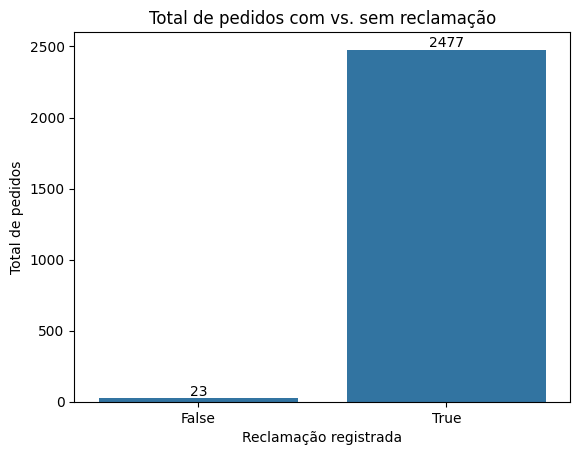

In [143]:
# Grafico de barras para representar total de pedidos com reclamação.
bar_graphic = sns.barplot(data = df_nps.groupby('has_complaints')['customer_id'].count().reset_index(), x = 'has_complaints', y='customer_id')
bar_graphic.bar_label(bar_graphic.containers[0])
plt.title('Total de pedidos com vs. sem reclamação')
plt.xlabel('Reclamação registrada')
plt.ylabel('Total de pedidos')
plt.show()

In [144]:
# Total de detratores que não fizeram pelo menos uma reclamação
print("Numero de detratores que não fizeram reclamação = " + str(df_nps[(df_nps['has_complaints'] == False) & (df_nps['is_detractor'] == True)]['customer_id'].count()))

Numero de detratores que não fizeram reclamação = 4


Dos clientes que não possuem reclamações, 4 (17,39%) são detratores.

In [145]:
# Estatisticas descritivas do NPS de pedidos com reclamação.
df_nps[df_nps['has_complaints'] == True]['nps_score'].describe()

,nps_score
count,2477.000000
mean,4.340170
std,2.486767
min,0.000000
25%,2.500000
50%,4.400000
75%,6.100000
max,10.000000


In [146]:
# Estatisticas descritivas do NPS de pedidos sem reclamação.
df_nps[df_nps['has_complaints'] == False]['nps_score'].describe()

,nps_score
count,23.000000
mean,8.517391
std,1.306853
min,6.000000
25%,7.800000
50%,8.700000
75%,10.000000
max,10.000000


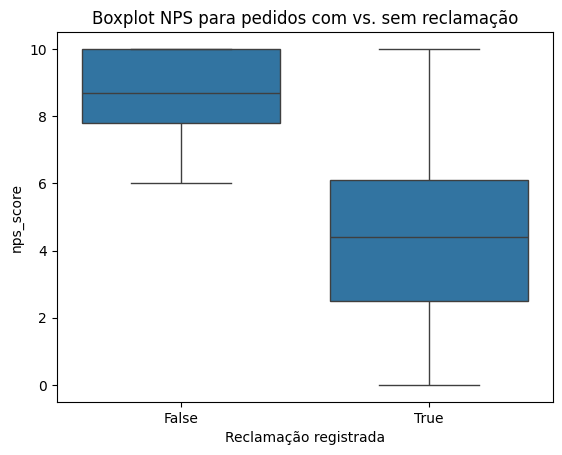

In [147]:
# Boxplot do NPS entrega em tempo X atrasada.
sns.boxplot(x='has_complaints', y='nps_score', data=df_nps)
plt.title('Boxplot NPS para pedidos com vs. sem reclamação')
plt.xlabel('Reclamação registrada')
plt.show()

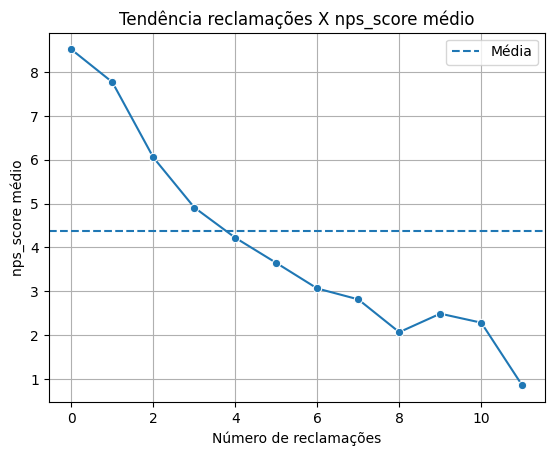

In [148]:
# Grafico de linha que mostra o impacto do número de reclamações na média de NPS.
sns.lineplot(data=df_nps.groupby('complaints_count')['nps_score'].mean().reset_index(), x='complaints_count', y='nps_score', marker='o')

# Traça uma linha de referência exatamente no valor médio do NPS score.
plt.axhline(df_nps['nps_score'].mean(), linestyle='--', label='Média')

plt.title('Tendência reclamações X nps_score médio')
plt.xlabel('Número de reclamações')
plt.ylabel('nps_score médio')
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_3979/1131811937.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



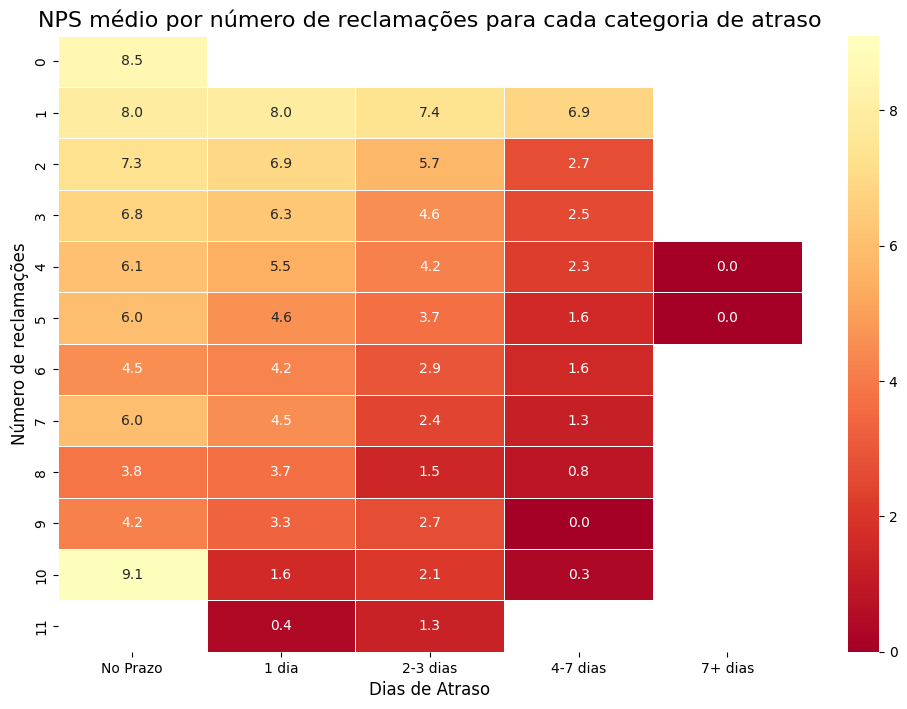

In [149]:
# Constroi um mapa de calor para visualizar o cruzamento de dias de atraso e número de reclamações no nps_score médio.
heatmap_data = df_nps.pivot_table(index='complaints_count', columns='delay_category', values='nps_score', aggfunc='mean')

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,       # Mostra o valor do NPS dentro de cada quadrado
    fmt=".1f",        # Formata para 1 casa decimal
    cmap="RdYlGn",    # Seleciona a escala de cores red, yellow, green
    center=9,         # Define 9 como ponto central, separando neutros de promotores.
    linewidths=.5    # Separa os quadrados do mapa com uma linha
    )

plt.title('NPS médio por número de reclamações para cada categoria de atraso', fontsize=16)
plt.xlabel('Dias de Atraso', fontsize=12)
plt.ylabel('Número de reclamações', fontsize=12)
plt.show()

In [150]:
# Registros sem atraso e com total de reclamações igual a 10. Apenas 1, o que explica a anomalia observada no gráfico.
df_nps[(df_nps['delayed'] == False) & (df_nps['complaints_count'] == 10)]['nps_score']

,nps_score
169,9.1


In [151]:
# Relação de quantos pedidos cada categoria de estimativa de entrega original possui.
df_nps.groupby('delivery_commit_category')['customer_id'].count()

/tmp/ipykernel_3979/300186222.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,customer_id
delivery_commit_category,
1 dia,168
2-3 dias,358
4-7 dias,777
7+ dias,930


In [152]:
# Pedidos com reclamação, agrupados por categoria de entrega original e de atraso.
df_nps[(df_nps['has_complaints'] == True)].groupby(['delivery_commit_category','delay_category'])['customer_id'].count()

/tmp/ipykernel_3979/1540377133.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



delivery_commit_category  delay_category
1 dia                     No Prazo            0
                          1 dia              50
                          2-3 dias           78
                          4-7 dias           40
                          7+ dias             0
2-3 dias                  No Prazo           35
                          1 dia             100
                          2-3 dias          162
                          4-7 dias           58
                          7+ dias             1
4-7 dias                  No Prazo           79
                          1 dia             183
                          2-3 dias          374
                          4-7 dias          132
                          7+ dias             1
7+ dias                   No Prazo          140
                          1 dia             282
                          2-3 dias          413
                          4-7 dias           82
                          7+ dias             0
Name: customer_id, dtype: int64

In [153]:
# Pedidos com promessa de entrega em até um dia, agrupados por categoria de atraso.
df_nps[(df_nps['delivery_commit_category'] == '1 dia') & (df_nps['delayed'] == True)].groupby('delay_category')['customer_id'].count()

/tmp/ipykernel_3979/2126484369.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,customer_id
delay_category,
No Prazo,0
1 dia,50
2-3 dias,78
4-7 dias,40
7+ dias,0


Percebemos que todos os pedidos com promessa original de 1 dia de entrega possuem reclamação.

Nenhum desses pedidos com promessa de entrega em 1 dia cumpriram essa estimativa. Todos eles tiveram atraso.

Para as outras estimativas de entrega, todos aqueles sem reclamação foram entregues no prazo.

In [154]:
# Taxa de recompra de clientes com nenhuma reclamação.
print("Taxa de recompra de clientes sem reclamação = " + str((df_nps[df_nps['has_complaints'] == False]['repeat_purchase_30d'].sum()/len(df_nps[df_nps['has_complaints'] == False])) * 100))

Taxa de recompra de clientes sem reclamação = 69.56521739130434


In [155]:
# Taxa de recompra de clientes com pelo menos uma reclamação.
print("Taxa de recompra de clientes com pelo menos uma reclamação = " + str((df_nps[df_nps['has_complaints'] == True]['repeat_purchase_30d'].sum()/len(df_nps[df_nps['has_complaints'] == True])) * 100))

Taxa de recompra de clientes com pelo menos uma reclamação = 8.155026241421073


Taxa de recompra 61.41% menor para clientes que fizeram pelo menos uma reclamação.

In [156]:
# Média de reclamações para pedidos atrasados, agrupados por categoria de atraso.
df_nps[(df_nps['has_complaints'] == True)].groupby('delay_category')['complaints_count'].describe()

/tmp/ipykernel_3979/713381439.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,count,mean,std,min,25%,50%,75%,max
delay_category,,,,,,,,
No Prazo,254.0,3.224409,1.871577,1.0,2.0,3.0,4.0,10.0
1 dia,615.0,4.144715,1.830843,1.0,3.0,4.0,5.0,11.0
2-3 dias,1171.0,4.282664,1.637028,1.0,3.0,4.0,5.0,11.0
4-7 dias,434.0,4.562212,1.641565,1.0,3.0,4.0,6.0,10.0
7+ dias,3.0,4.333333,0.577350,4.0,4.0,4.0,4.5,5.0


## Análise de atendimento ao cliente

In [157]:
print("Clientes que contataram o atendimento, tiveram reclamação e não tiveram atraso na entrega: " + str(df_nps[(df_nps['contacted_support'] == True) & (df_nps['has_complaints'] == True) & (df_nps['delayed'] == False)]['customer_id'].count()))
print("Desse número, quantos repetiram a compra no período de 30 dias? " + str(df_nps[(df_nps['contacted_support'] == True) & (df_nps['has_complaints'] == True) & (df_nps['delayed'] == False) & (df_nps['repeat_purchase_30d'] == 1)]['customer_id'].count()))

Clientes que contataram o atendimento, tiveram reclamação e não tiveram atraso na entrega: 212
Desse número, quantos repetiram a compra no período de 30 dias? 51


75,94% dos clientes que contataram atendimento ao cliente e não tiveram atraso na entrega não voltaram a comprar após 30 dias

In [158]:
# NPS médio de clientes que contataram atendimento ao cliente, têm reclamação e não tiveram atraso.
df_nps[(df_nps['contacted_support'] == True) & (df_nps['has_complaints'] == True) & (df_nps['delayed'] == False)].groupby(['customer_service_contacts', 'resolution_time_days'])['nps_score'].mean()

customer_service_contacts  resolution_time_days
1                          0                       9.120000
                           1                       8.200000
                           2                       7.300000
                           3                       8.483333
                           4                       8.371429
                           5                       8.500000
                           6                       6.414286
                           7                       7.457143
                           8                       6.100000
                           9                       5.800000
                           10                      7.450000
                           11                      5.733333
2                          0                       6.825000
                           1                       6.675000
                           2                       7.166667
                           3                       6.771429
                           4                       7.400000
                           5                       5.120000
                           6                       6.483333
                           7                       6.600000
                           8                       5.860000
                           9                       5.925000
                           10                      5.285714
                           11                      5.562500
3                          0                       7.400000
                           1                       6.060000
                           2                       8.800000
                           3                       3.900000
                           4                       6.100000
                           5                       6.733333
                           6                       2.600000
                           7                       6.266667
                           8                       6.633333
                           9                       4.050000
                           10                      5.750000
                           11                      4.025000
4                          0                       5.250000
                           1                       9.100000
                           2                       7.000000
                           3                       5.900000
                           5                       4.866667
                           6                       4.700000
                           7                       2.300000
                           9                       3.700000
                           10                      4.550000
5                          0                       7.000000
                           1                       4.600000
                           3                       4.100000
                           5                       4.000000
Name: nps_score, dtype: float64

Visando reduzir o número de detratores, o esforço deve ser para resolução de problemas no primeiro contato do cliente.

No primeiro contato, temos até 5 dias para resolução até que o cliente se torne um detrator.

A partir do segundo contato, mesmo com resolução no mesmo dia, em média ele já se tornou detrator.